In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
) 

In [89]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import make_scorer, f1_score

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder 

In [79]:
from sklearn.compose import ColumnTransformer 

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

### Task 1 — Unsupervised Exploration

1. Load the Palmer Penguins dataset (`sns.load_dataset("penguins")`). 

In [59]:
penguins = sns.load_dataset("penguins") 

In [60]:
df = pd.DataFrame(penguins)

In [61]:
df_copy = df.copy() 

In [62]:
# I will drop rows that ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"] are nans. 
# Because they don't have important features only with island and species we can't predict these 4 columns. 
# What we can do is this we can drop them but keep columns that only sex column is nan and using other columns we can predict sex column and fill them. 

2. Clean the data: handle missing values, examine distributions, and note any anomalies. 

In [63]:
cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g" 
]

df_copy = df_copy.dropna(subset=cols)

train = df_copy[df_copy['sex'].notna()]
test  = df_copy[df_copy['sex'].isna()]

X_train = pd.get_dummies(train[cols + ['species', 'island']])
X_test  = pd.get_dummies(test[cols + ['species', 'island']])

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train['sex']

model = RandomForestClassifier(
    n_estimators=300,
    random_state=0
)

model.fit(X_train, y_train)

df_copy.loc[df_copy['sex'].isna(), 'sex'] = model.predict(X_test)

print(df_copy.isna().sum()) 

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [64]:
# Distribution and outliers for cleaned dataset

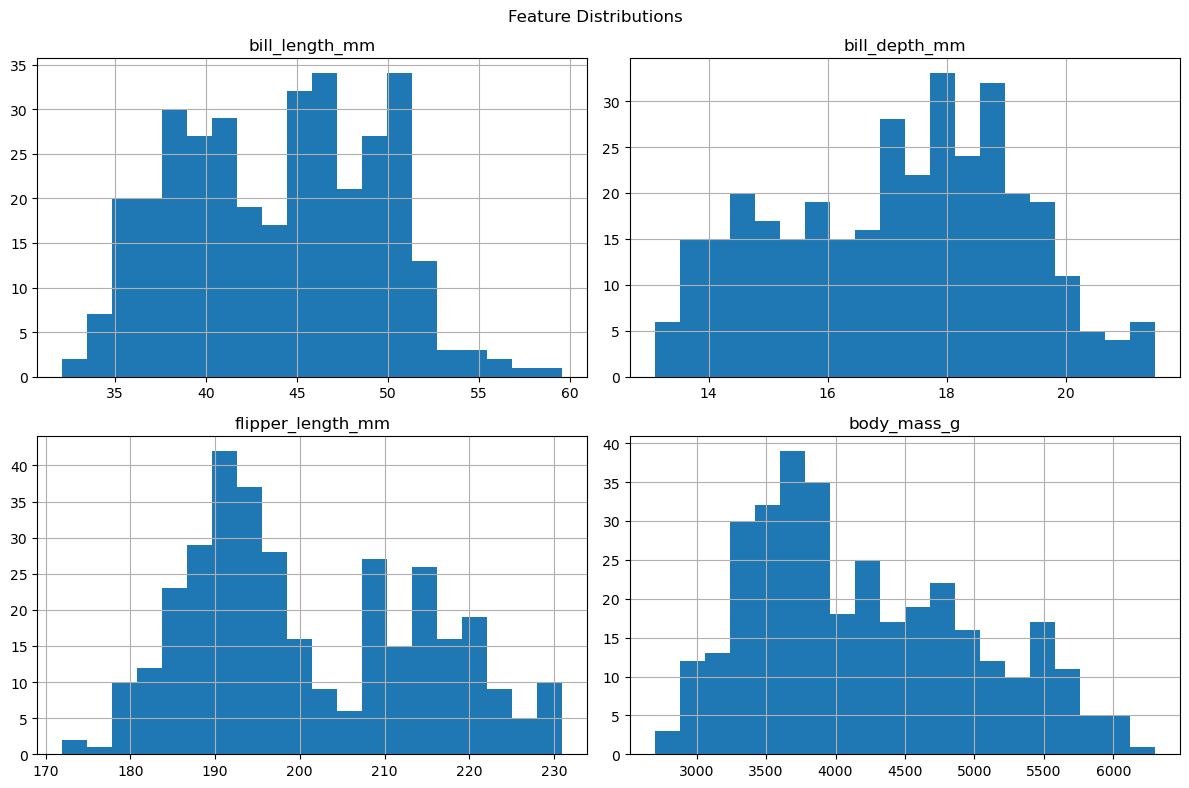

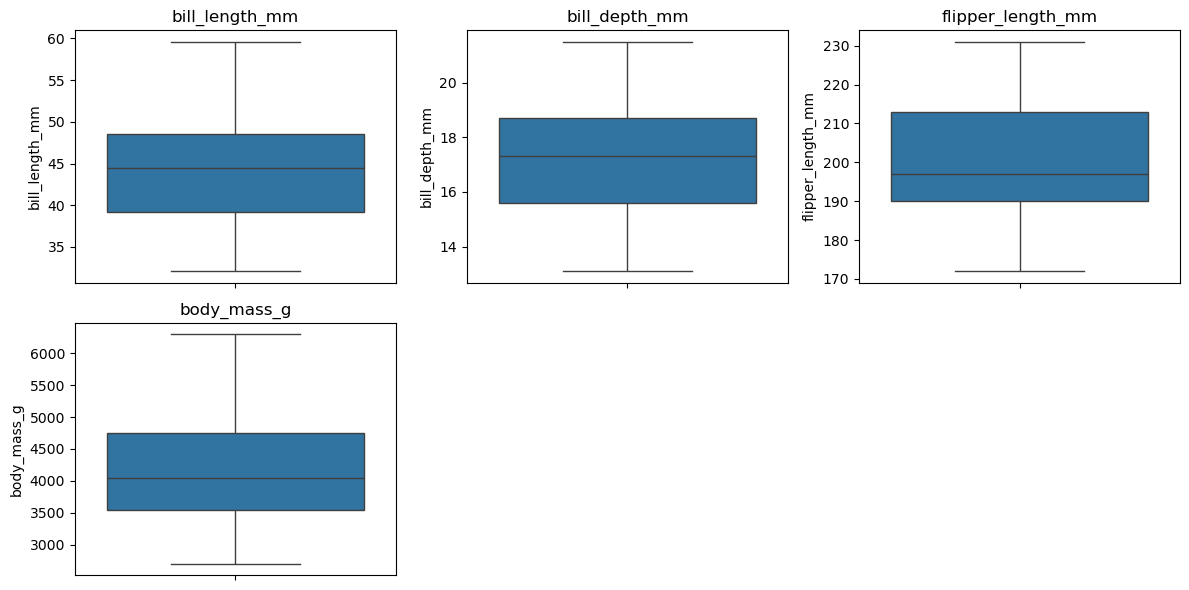

In [65]:
numeric_cols = df_copy.select_dtypes(include=np.number).columns

df_copy[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_copy[col])
    plt.title(col)

plt.tight_layout()
plt.show() 

In [66]:
numeric_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

for col in numeric_cols:
    
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = len(
        df_copy[
            (df_copy[col] < lower) |
            (df_copy[col] > upper)
        ]
    )

    print(f"{col}: {outlier_count} outliers")

bill_length_mm: 0 outliers
bill_depth_mm: 0 outliers
flipper_length_mm: 0 outliers
body_mass_g: 0 outliers


In [67]:
# Distribution and outliers for raw dataset

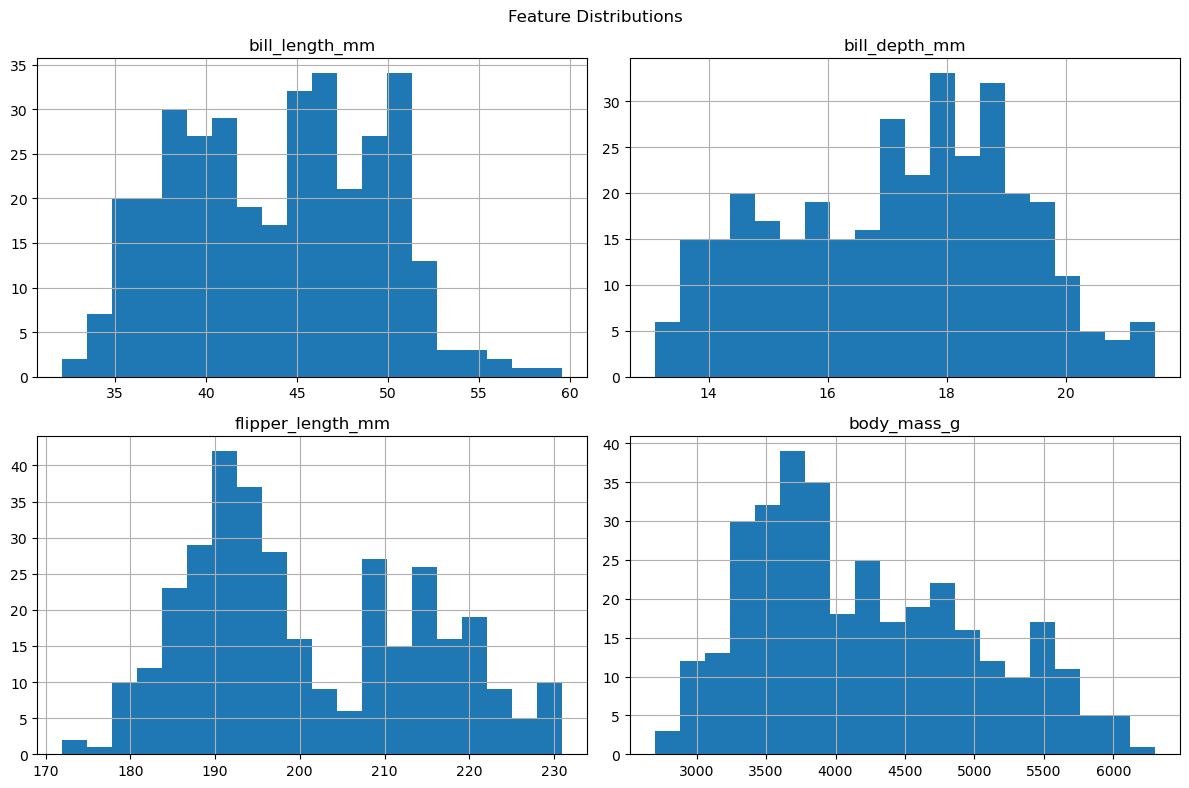

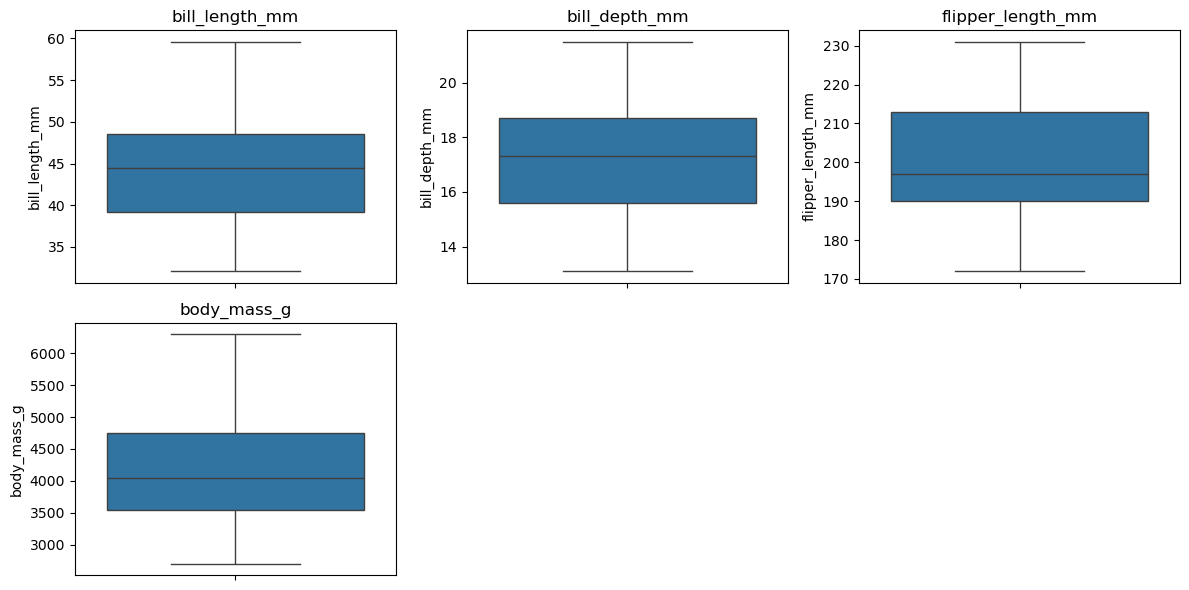

In [68]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show() 

In [69]:
numeric_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = len(
        df[
            (df[col] < lower) |
            (df[col] > upper)
        ]
    )

    print(f"{col}: {outlier_count} outliers")

bill_length_mm: 0 outliers
bill_depth_mm: 0 outliers
flipper_length_mm: 0 outliers
body_mass_g: 0 outliers


In [70]:
# as you can see there is not any outlier for both dataset.

3. Select the numeric features and scale them with `StandardScaler`.

In [71]:
X = df_copy[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

4. Apply **PCA** (2 components) and **t-SNE** (2 components, `random_state=42`). Create a side-by-side plot colored by actual species.

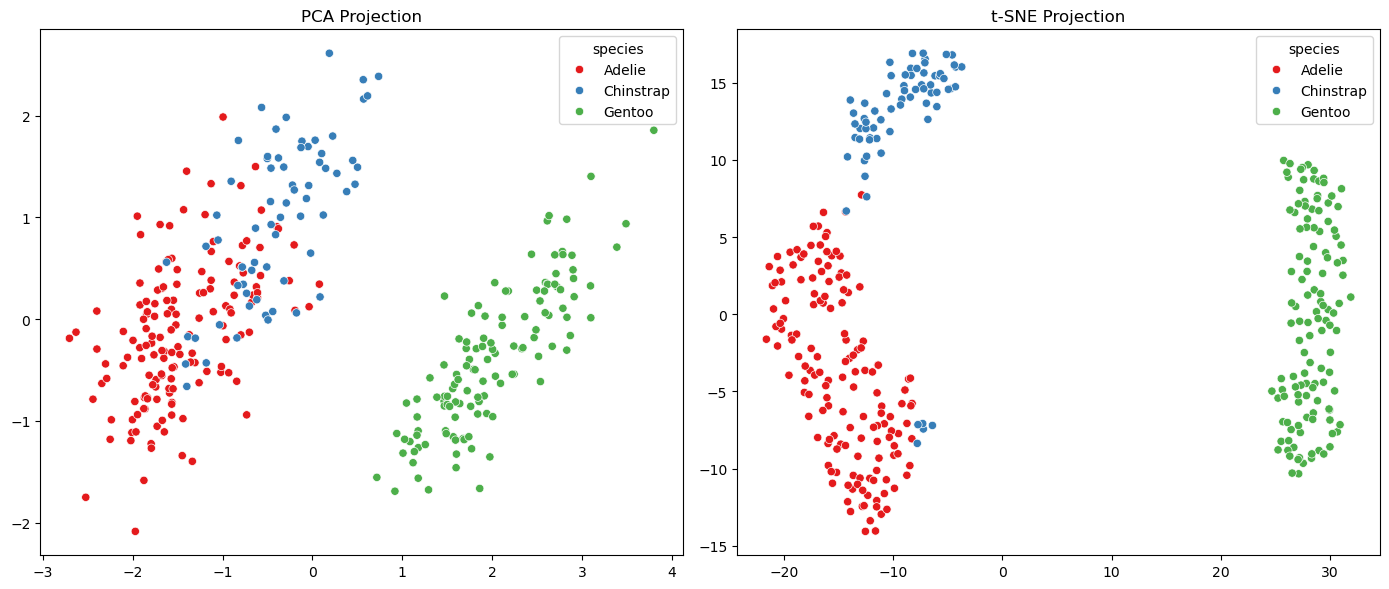

In [72]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

species = df_copy["species"]

# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA plot
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=species,
    palette="Set1",
    ax=axes[0]
)

axes[0].set_title("PCA Projection")

# t-SNE plot
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=species,
    palette="Set1",
    ax=axes[1]
)

axes[1].set_title("t-SNE Projection")

plt.tight_layout()
plt.show() 

5. Apply **K-Means** (k=3) and **DBSCAN** (experiment with at least 2 `eps`/`min_samples` combos) to the scaled data.
6. Evaluate each clustering result with the **silhouette score**. 

In [73]:
# ----- K-Means -----
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# ----- DBSCAN (Experiment 1) -----
dbscan1 = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan1_labels = dbscan1.fit_predict(X_scaled)

# ----- DBSCAN (Experiment 2) -----
dbscan2 = DBSCAN(
    eps=0.8,
    min_samples=4
)

dbscan2_labels = dbscan2.fit_predict(X_scaled)


# --------------------------------------------
# 6. Silhouette Scores
# --------------------------------------------

print("\n--- Silhouette Scores ---")

# KMeans
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print("K-Means:", round(kmeans_sil, 3))

# DBSCAN 1
if len(set(dbscan1_labels)) > 1 and -1 not in set(dbscan1_labels):
    db1_sil = silhouette_score(X_scaled, dbscan1_labels)
else:
    db1_sil = "Not valid"

print("DBSCAN (eps=0.5, min_samples=5):", db1_sil)

# DBSCAN 2
valid_mask = dbscan2_labels != -1

if len(set(dbscan2_labels[valid_mask])) > 1:
    db2_sil = silhouette_score(
        X_scaled[valid_mask],
        dbscan2_labels[valid_mask]
    )
else:
    db2_sil = "Not valid"

print("DBSCAN (eps=0.8, min_samples=4):", db2_sil) 


--- Silhouette Scores ---
K-Means: 0.447
DBSCAN (eps=0.5, min_samples=5): Not valid
DBSCAN (eps=0.8, min_samples=4): 0.5357341147420731


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


7. Compare your best clustering labels to the actual species using **adjusted Rand score** and **normalized mutual information**. Visualize the comparison on a PCA projection.


--- Clustering vs True Species ---
Adjusted Rand Score: 0.647
Normalized Mutual Information: 0.73


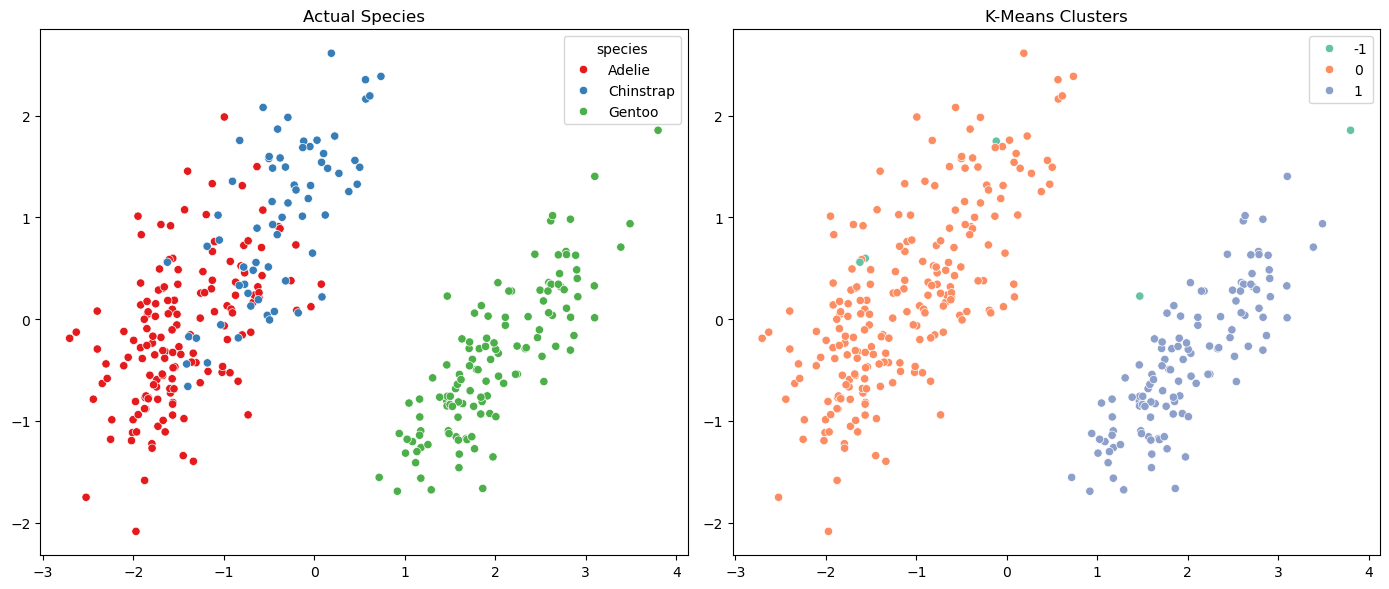

In [74]:
true_labels = species

ari = adjusted_rand_score(true_labels, dbscan2_labels)
nmi = normalized_mutual_info_score(true_labels, dbscan2_labels)

print("\n--- Clustering vs True Species ---")
print("Adjusted Rand Score:", round(ari, 3))
print("Normalized Mutual Information:", round(nmi, 3))


# Visualization on PCA projection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual species
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=true_labels,
    palette="Set1",
    ax=axes[0]
)

axes[0].set_title("Actual Species")

# Predicted clusters
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=dbscan2_labels,
    palette="Set2",
    ax=axes[1]
)

axes[1].set_title("DBSCAN 2 Clusters")

plt.tight_layout()
plt.show() 


--- Clustering vs True Species ---
Adjusted Rand Score: 0.793
Normalized Mutual Information: 0.786


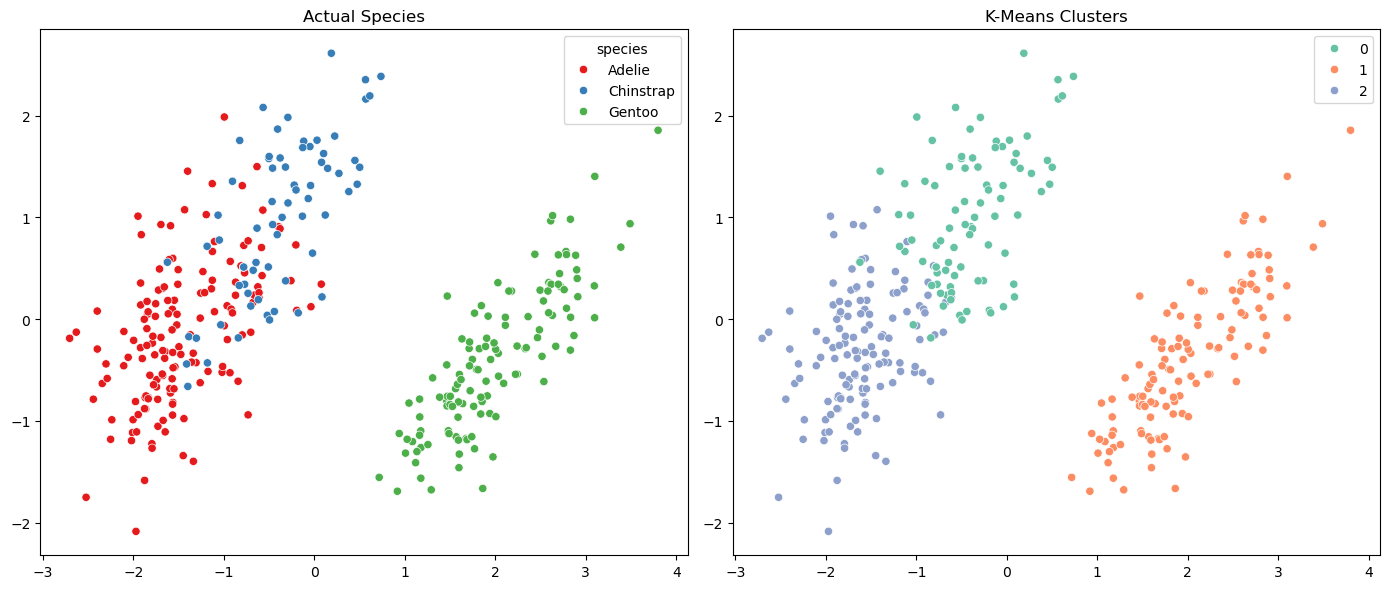

In [75]:
true_labels = species

ari = adjusted_rand_score(true_labels, kmeans_labels)
nmi = normalized_mutual_info_score(true_labels, kmeans_labels)

print("\n--- Clustering vs True Species ---")
print("Adjusted Rand Score:", round(ari, 3))
print("Normalized Mutual Information:", round(nmi, 3))


# Visualization on PCA projection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual species
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=true_labels,
    palette="Set1",
    ax=axes[0]
)

axes[0].set_title("Actual Species")

# Predicted clusters
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels,
    palette="Set2",
    ax=axes[1]
)

axes[1].set_title("K-Means Clusters")

plt.tight_layout()
plt.show() 

8. In a markdown cell, summarize: How well did unsupervised methods recover the species structure? Where did they fail? 

```
How well the structure was recovered
Both PCA and t-SNE visualizations showed clear grouping of the data, suggesting that the species have meaningful structure in feature space.
K-Means clustering was able to identify the three main groups fairly well, aligning reasonably with the actual species labels.
DBSCAN also identified clusters based on density and achieved a higher silhouette score in one configuration, indicating compact local groupings.
Where the methods failed
There is overlap between species (especially Adelie and Chinstrap), which caused misclassification in all clustering methods.
K-Means assumes spherical clusters, so it cannot capture irregular boundaries between species perfectly.
DBSCAN is highly sensitive to parameter choices (eps, min_samples) and sometimes labeled valid points as noise or merged clusters incorrectly.
Neither method fully captured the true biological separation between species, since some features are similar across groups.
```

### Task 2 — Supervised Model Pipeline

1. Prepare the full dataset for supervised classification: target = `species`, features = all other columns.

In [76]:
df = df.dropna() 

X = df.drop(columns=["species"]) 
y = df["species"] 

2. Drop rows with missing values using `dropna()`, then build a preprocessing pipeline using `ColumnTransformer`:
   - Numeric features: scale (`StandardScaler`).
   - Categorical features: one-hot encode (`OneHotEncoder`).

In [82]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
) 

3. Train and evaluate **at least 3 different models** (e.g., LogisticRegression, RandomForest, SVC) using **stratified 5-fold cross-validation**. Report accuracy, precision (macro), recall (macro), and F1 (macro) for each.

In [87]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "SVC": SVC()
} 

In [90]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    
    results[name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean()
    }

results_df = pd.DataFrame(results).T.sort_values(by="f1", ascending=False)
print(results_df) 

                  accuracy  precision    recall        f1
KNN               0.993939   0.990794  0.995402  0.992893
LogReg            0.994030   0.995833  0.989744  0.992294
SVC               0.994030   0.995833  0.989744  0.992294
RandomForest      0.991000   0.988643  0.990274  0.989133
GradientBoosting  0.987969   0.988961  0.985033  0.986625
ExtraTrees        0.988014   0.988849  0.982683  0.985056


4. Select the best model based on F1 score.

In [91]:
best_model_name = results_df["f1"].idxmax()
print("Best model:", best_model_name)

Best model: KNN


In [92]:
best_model = models[best_model_name] 

5. Define a hyperparameter grid (at least 3 parameters) and run `GridSearchCV` with stratified 5-fold CV. 

In [93]:
param_grids = {
    "RandomForest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5, 10]
    },
    
    "GradientBoosting": {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__max_depth": [1, 3, 5]
    },
    
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"]
    },
    
    "SVC": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"]
    }
} 

In [94]:
best_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", best_model)
])

grid = GridSearchCV(
    best_pipe,
    param_grid=param_grids[best_model_name],
    cv=cv,
    scoring="f1_macro"
)

grid.fit(X, y)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


6. Report the best parameters, best CV score, and compare with the default model performance. 

In [95]:
print("Best model:", best_model_name)
print("Best parameters:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

Best model: KNN
Best parameters: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Best CV F1 score: 0.996361273554256


In [96]:
# as you can see default was 0.992893, new is 0.996361. the result was alread good, so it has improved slightly.  

### Task 3 — Model Evaluation & Interpretation

Using the best tuned model from Task 2:

1. Train on the full training set and predict on a held-out test set (80/20 split, `random_state=42`).

In [97]:
best_model = grid.best_estimator_

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

2. Print the full **classification report**. 

In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



3. Plot the **confusion matrix** using `ConfusionMatrixDisplay`. 

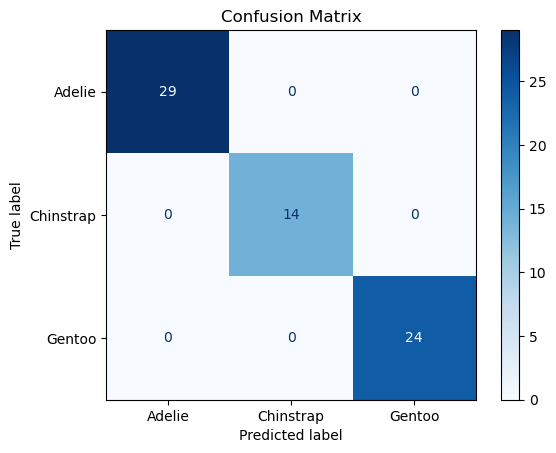

In [100]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

4. Plot **ROC curves** (one-vs-rest) for all three species on the same figure. Compute and display the AUC for each class. (If your model doesn't natively support `predict_proba`, wrap it in a `CalibratedClassifierCV` or switch to a model that does.)

In [101]:
from sklearn.calibration import CalibratedClassifierCV

best_model_proba = CalibratedClassifierCV(best_model, cv=5)
best_model_proba.fit(X_train, y_train) 

,estimator,Pipeline(step...'distance'))])
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


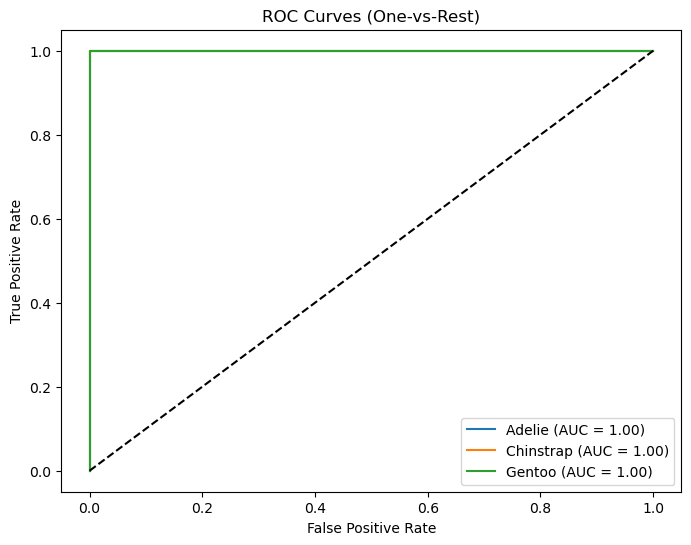

In [102]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

classes = np.unique(y)

y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_model_proba.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

5. Plot **learning curves** (training size from 10% to 100%). 

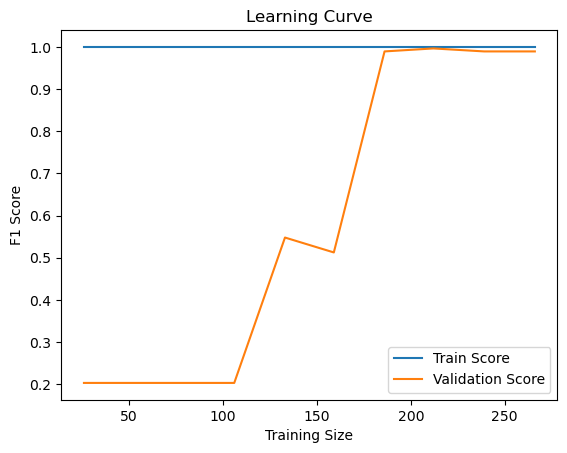

In [103]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="f1_macro"
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()
plt.show() 

6. Compute **permutation importances** on the test set and plot the top features.

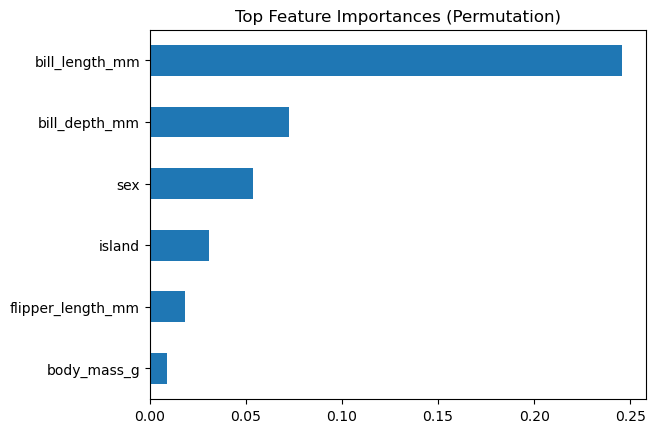

In [104]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

importances = pd.Series(result.importances_mean, index=X.columns)
importances.sort_values().tail(10).plot(kind="barh")

plt.title("Top Feature Importances (Permutation)")
plt.show() 

7. In a markdown cell, write a comprehensive interpretation:
   - Is the model overfitting or underfitting?
   - Which species is hardest to classify and why?
   - Which features drive predictions the most?
   - Are there any signs of data leakage or evaluation issues?  

In [ ]:
# Validation score increase over time, if it was low, training was high we could say it is overfitting but in this case it is not completely overfit even though the score is close to 1. But there is a tendecy though 
# we see the model could find all species correctly, so there is not any specific specy the model struggled to find 
# mostly the first one in permutation visualization(bill_length_mm)
# there is actually because model looks like overfit, and data leakage can be one of the reasons. 

### Task 4 — Model Deployment Prototype 

1. Serialize the best tuned model (full pipeline including preprocessor) using `joblib.dump()`. 

In [105]:
import joblib

joblib.dump(grid.best_estimator_, "penguin_model.pkl")

['penguin_model.pkl']

In [108]:
import requests

sample = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "species": "Adelie",   
    "island": "Torgersen",
    "sex": "Male"
}

response = requests.post("http://127.0.0.1:5000/predict", json=sample)

print(response.status_code)
print(response.json()) 

200
{'predicted_species': 'Adelie', 'probabilities': {'Adelie': 1.0, 'Chinstrap': 0.0, 'Gentoo': 0.0}}


In [109]:
bad_sample = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7
}

response = requests.post("http://127.0.0.1:5000/predict", json=bad_sample)

print(response.status_code)
print(response.json())

400
{'error': 'Missing feature: flipper_length_mm'}


## Penguin Species Prediction API

### Endpoint: `/predict`
**Method:** POST  
**Description:** Predicts penguin species using a trained machine learning model.

---

### Input Format
The API expects a JSON object with penguin measurements:

```json
{
  "bill_length_mm": 39.1,
  "bill_depth_mm": 18.7,
  "flipper_length_mm": 181.0,
  "body_mass_g": 3750,
  "species": "Adelie",
  "island": "Torgersen",
  "sex": "Male"
} 